**Pennylane**: biblioteca de software para programación de algoritmos cuánticos

Algoritmo cuántico (**QAOA**) para resolver el problema de **MaxCut**: se tiene un grafo y se quiere dividir los nodos en dos grupos para maximizar cuántas conexiones quedan “cortadas” entre grupos.

El tutorial enseña a: construir el problema en un circuito cuántico, usar puertas cuánticas (RX, RZ, CNOT), optimizar parámetros con un optimizador clásico y obtener la mejor partición del grafo == usar un ordenador cuántico simulado para encontrar una solución aproximada a un problema de optimización difícil.

Se toma un grafo con vértices y aristas.
Se divide el conjunto de vértices en dos subconjuntos.
Se busca maximizar cuántas conexiones quedan entre grupos distintos. Podemos representar cada partición con una cadena de bits:

0 → vértice en el conjunto A
1 → vértice en el conjunto B

Por ejemplo:
Un bitstring como 0101 indica qué vértices están en cada grupo.

El objetivo es encontrar el bitstring que maximiza el número de aristas cortadas

In [1]:
!pip install pennylane



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 92.0 MB/s eta 0:00:00


In [2]:
import pennylane as qml
from pennylane import numpy as np

np.random.seed(42)

We specify the number of qubits (vertices) with **n_wires** and compose the unitary operators using the definitions above. **UB operators act on individual wires**, while **UC operators act on wires whose corresponding vertices are joined by an edge in the graph**. We also define the graph using the list **graph**, which contains the tuples of vertices defining each edge in the graph.

In [3]:
n_wires = 4
graph = [(0, 1), (0, 3), (1, 2), (2, 3)] #Cada tupla (i, j) significa: “hay una conexión entre el nodo i y el nodo j”


# unitary operator U_B with parameter beta
def U_B(beta):
    for wire in range(n_wires):
        qml.RX(2 * beta, wires=wire)


# unitary operator U_C with parameter gamma
def U_C(gamma):
    for edge in graph:
        qml.CNOT(wires=edge)
        qml.RZ(gamma, wires=edge[1])
        qml.CNOT(wires=edge)
        # Could also do
        # IsingZZ(gamma, wires=edge)

Vamos a necesitar una forma de convertir un bitstring (cadena de bits), que representa una muestra de varios qubits en la base computacional, a un número entero o en base 10. (es más fácil trabajar con números enteros que con cadenas de bits). Ejemplos: 0101₂ = 5₁₀
1010₂ = 10₁₀

In [4]:
def bitstring_to_int(bit_string_sample):
    return int(2 ** np.arange(len(bit_string_sample)) @ bit_string_sample[::-1])

Circuit: we create a quantum device with 4 qubits. “simulador” o “hardware” donde se ejecuta el circuito cuántico.

Cada qubit representa si un nodo está en el grupo A o B del MaxCut. 4 qubits= 16 estados posibles.(todos se estudian a la vez)

In [5]:
dev = qml.device("lightning.qubit", wires=n_wires)

**Nodo cuántico** que aplicará los operadores según los **parámetros de ángulo**, y devolverá el **Valor esperado del Hamiltoniano de coste**. (función que ejecuta el circuito cuántico).

Entradas: los parámetros **gammas** y **betas**, que determinan el **número de capas** del circuito, según su **longitud**.



**return_samples**: Este parámetro cambia el comportamiento


False → devuelve el valor promedio (para optimización)
True → devuelve resultados concretos (bitstrings)

In [6]:
@qml.set_shots(20)   #cada ejecución mide el circuito 20 veces (importante para estadística)
@qml.qnode(dev)  #convierte la función en un circuito cuántico ejecutable,convierte una función en una máquina cuántica programable que puedes optimizar con gradientes._
def circuit(gammas, betas, return_samples=False):
    # apply Hadamards to get the n qubit |+> state, así se crea superposición de todos los estados posibles
    for wire in range(n_wires):
        qml.Hadamard(wires=wire)

    for gamma, beta in zip(gammas, betas):   #cada par es una capa
        U_C(gamma)  #aplica el coste (problema MaxCut)
        U_B(beta)   #mezcla estados (explora soluciones)

    if return_samples:
        # modo de muestreo del circuito en el que devuelve solución, bistrings
        return qml.sample()
    # Calcula el valor esperado del coste. Usa operadores Z (medición en eje Z). Evalúa qué tan buena es la solución en promedio
    C = qml.sum(*(qml.Z(w1) @ qml.Z(w2) for w1, w2 in graph))
    return qml.expval(C)

#Convierte el problema en minimización, objective es el numero de aristas que se cortan que debe ser 4 en el mejor caso
def objective(params):
    return -0.5 * (len(graph) - circuit(*params))


Las optimizaciones en PennyLane se formulan como problemas de minimización.El problema real es maximizar el MaxCut, pero l**os optimizadores clásicos trabajan mejor minimizando**

**maximizar la función original = minimizar su versión negativa**

In [7]:
def qaoa_maxcut(n_layers=1):
    print(f"\np={n_layers:d}")

    # initialize the parameters near zero
    init_params = 0.01 * np.random.rand(2, n_layers, requires_grad=True)

    # initialize optimizer: Adagrad works well empirically
    opt = qml.AdagradOptimizer(stepsize=0.5)    #Algoritmo clásico que ajusta parámetros, decide cómo cambiar γ y β

    # optimize parameters in objective
    params = init_params.copy()
    steps = 30
    for i in range(steps):
        params = opt.step(objective, params) #Cada iteración:Ejecuta el circuito, evalúa resultado y Ajusta parámetros,se mueve en dirección que reduce la energía
        if (i + 1) % 5 == 0:
            print(f"Objective after step {i+1:3d}: {-objective(params): .7f}")

    # sample 100 bitstrings by setting return_samples=True and the QNode shot count to 100== Ejecuta el circuito optimizado 100 veces
    bitstrings = qml.set_shots(circuit, shots=100)(*params, return_samples=True)
    # convert the samples bitstrings to integers, para las gráficas y conteo
    sampled_ints = [bitstring_to_int(string) for string in bitstrings]

    # print optimal parameters and most frequently sampled bitstring
    counts = np.bincount(np.array(sampled_ints))
    most_freq_bit_string = np.argmax(counts)
    print(f"Optimized parameter vectors:\ngamma: {params[0]}\nbeta:  {params[1]}")
    print(f"Most frequently sampled bit string is: {most_freq_bit_string:04b}")

    return -objective(params), sampled_ints


# perform QAOA on our graph with p=1,2 and keep the lists of sampled integers, Ejecuta el algoritmo con 1capa y 2

int_samples1 = qaoa_maxcut(n_layers=1)[1]
int_samples2 = qaoa_maxcut(n_layers=2)[1]



p=1
Objective after step   5:  2.7000000
Objective after step  10:  2.6000000
Objective after step  15:  2.8000000
Objective after step  20:  3.1000000
Objective after step  25:  2.5000000
Objective after step  30:  2.8000000
Optimized parameter vectors:
gamma: [-0.85012621]
beta:  [-1.1387739]
Most frequently sampled bit string is: 0101

p=2
Objective after step   5:  3.9000000
Objective after step  10:  4.0000000
Objective after step  15:  4.0000000
Objective after step  20:  3.7000000
Objective after step  25:  4.0000000
Objective after step  30:  4.0000000
Optimized parameter vectors:
gamma: [-0.87006543 -1.12209739]
beta:  [0.60119142 0.4741234 ]
Most frequently sampled bit string is: 1010


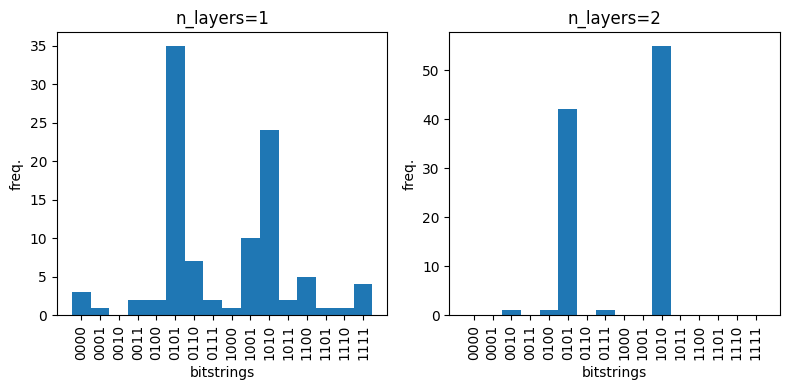

In [8]:
import matplotlib.pyplot as plt

xticks = range(0, 16)
xtick_labels = list(map(lambda x: format(x, "04b"), xticks))
bins = np.arange(0, 17) - 0.5

fig, _ = plt.subplots(1, 2, figsize=(8, 4))
for i, samples in enumerate([int_samples1, int_samples2], start=1):
    plt.subplot(1, 2, i)
    plt.title(f"n_layers={i}")
    plt.xlabel("bitstrings")
    plt.ylabel("freq.")
    plt.xticks(xticks, xtick_labels, rotation="vertical")
    plt.hist(samples, bins=bins)
plt.tight_layout()
plt.show()